In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
from matplotlib_venn import venn2
import upsetplot

In [173]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function
import warnings
import scanpy as sc
from ast import literal_eval
from collections import Counter

cancer_gene_tb = pd.read_csv("D:/02.project/18.ecDNA/02.method/ref/hg19/cancer_gene_census_20240307.txt",sep="\t")
cancer_gene_list = list(cancer_gene_tb["Gene Symbol"].unique())

# DataFrame :: gene_unique_list is the column list of elements that match oncogenes
def custom_transform(element):
    if isinstance(element, list):
        # Extract the intersection of the element list with oncogene_list
        return list(set(element) & set(cancer_gene_list))
    else:
        # If the element is NaN, then return NaN
        return element
### step 1
# Apply the custom function custom_transform to the gene_unique_list column
#df['oncogene'] = df['gene_unique_list'].apply(custom_transform)

# Define a function to process elements in the oncogene column:: convert oncogene_nor element value 0 to []
def process_gene_list(item):
    # If the element is the integer 0, return an empty list
    if item == 0:
        return []
    # Otherwise, return the original element
    else:
        return item
# Define a function to process elements in the oncogene_nor column:: merge oncogene_nor list
def merge_gene_list(gene_list):
    # Create an empty list to store the results
    result = []
    for item in gene_list:
        # If the element is a list, add its elements to the result
        if isinstance(item, list):
            result.extend(item)
    return result
# Define a function to process elements in the oncogene_nor column
def process_oncogene_nor(oncogene_nor, top_n=15):
    # Use Counter to count the frequency of elements
    counter = Counter(oncogene_nor)
    # Extract the top_n elements with the highest frequency
    most_common = counter.most_common(top_n) # 6/15
    # Form a list with these top_n elements
    result = [item[0] for item in most_common]
    return result
### Main function merge
def group_merge(df=pd.DataFrame(), group_columns_name="group", raw_columns_name="oncogene"):
    df_ecdna_gene = df.copy()
    # Use the apply function
    df_ecdna_gene[raw_columns_name+"_nor"] = df_ecdna_gene[raw_columns_name].apply(process_gene_list)
    # Use groupby and apply functions
    df_ecdna_gene_grouped = df_ecdna_gene.groupby(group_columns_name)[raw_columns_name+"_nor"].apply(merge_gene_list).reset_index()
    # Convert the label column to Categorical type and specify the order of categories
    df_ecdna_gene_grouped[group_columns_name] = pd.Categorical(df_ecdna_gene_grouped[group_columns_name],
                                                    categories=list(df_ecdna_gene[group_columns_name].unique()),
                                                    ordered=True)
    # Use the sort_values function to sort
    df_ecdna_gene_grouped = df_ecdna_gene_grouped.sort_values(group_columns_name)
    # Use the apply function
    df_ecdna_gene_grouped['most_'+raw_columns_name+"_nor"] = df_ecdna_gene_grouped[raw_columns_name+"_nor"].apply(process_oncogene_nor)
    return df_ecdna_gene_grouped

### step 2
# Apply the custom function group_merge to the gene oncogene column
#df_merge = group_merge(df_ecdna_gene_oncogene, "group")



###共性基因功能注释：：
# highest_expr_top_n
import gseapy as gp
from gseapy.plot import barplot, dotplot
"""
names = gp.get_library_name()
# Create a DataFrame from the list
df = pd.DataFrame(names, columns=['Name'])
# Save the DataFrame to a CSV file
df.to_csv("./fig/gseapy_gene-sets.txt", index=False)
"""

import pandas as pd
# 定义一个函数来处理字符串
def process_term(term):
    # 检查倒数第12个到倒数第9个字符是否为'(GO:'
    if term[-12:-8] == '(GO:':
        # 如果是，则删除倒数第11个字符之后的所有字符
        return term[:-12]
    else:
        # 否则，返回原字符串
        return term

def gp_enrichr(gene_list,sample,path,gene_sets=['MSigDB_Hallmark_2020']):
    # 假设你已经有了差异基因列表
    #gene_sets=['MSigDB_Hallmark_2020',
    #           'KEGG_2021_Human',
    #           'GO_Biological_Process_2023',
    #           'GO_Molecular_Function_2023',
    #           'GO_Cellular_Component_2023']

    diff_genes = gene_list
    #diff_genes = new_df[new_df["cluster"]=="C3"]["gene"].to_list()
    #diff_genes = new_df["gene"].to_list()
    # 运行GSEA
    # enrichr库包含了大量的基因集，选择其中的一个，例如'KEGG_2019_Human'\'MSigDB_Hallmark_2020'
    enr = gp.enrichr(gene_list=diff_genes,
                     gene_sets=gene_sets,
                     #outdir='./fig/pdac/gseapy',
                     outdir=None,
                     cutoff=0.05)
    
    enr.results["Term_raw"]=enr.results["Term"]
    # 使用apply函数应用到'Term'列
    enr.results["Term"] = enr.results["Term"].apply(process_term)
    # trim (go:...)
    #enr.results["Term"] = enr.results["Term"].str.split(" \(GO").str[0]
    # 根据'A'列的值对df进行排序
    enr_results_sorted = enr.results.sort_values(by='P-value')
    enr_results_sorted['cluster'] = sample
    enr_results_sorted.to_csv(path+"/"+sample+"_enrichr_result.tsv",sep="\t",index=True)
    
    # categorical scatterplot
    #ax = barplot(enr_results_sorted,
    #             #column="Adjusted P-value",
    #             column="P-value",
    #             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
    #             #size=10,
    #             top_term=30,
    #             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
    #             figsize=(35,12),
    #             color=['blue'] # set colors for group
    #             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
    #             )
    #plt.grid(False)
    #plt.savefig(path+"/"+sample+"_enrichr_barplot.pdf")
    return enr_results_sorted

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Function to generate 10 random colors
def generate_random_colors(num_colors=10):
    return [np.random.rand(3,) for _ in range(num_colors)]
# Generate random colors
random_colors = generate_random_colors(10)

# Define a Morandi-style color palette (soft, muted, pastel-like colors)
morandi_colors = [
    '#D8BFD8',  # Thistle
    '#B4A6A4',  # Light grayish brown
    '#A89F91',  # Grayish olive green
    '#C9ADA1',  # Soft pinkish beige
    '#D0B0A1',  # Light brownish pink
    '#B4A8A1',  # Light mauve
    '#C4A1C1',  # Soft lavender
    '#D7C2A1',  # Light beige
    '#E0C9B9',  # Light warm gray
    '#BFB8B1'   # Soft beige
]
# Define a bright and high-contrast Morandi-inspired color palette
bright_morandi_colors = [
  '#F8C8D3',  # Soft pink
  '#F7E3A1',  # Light pastel yellow
  '#C2D8A3',  # Light green
  '#F1B7C1',  # Soft peach
  '#A8D6E1',  # Light blue
  '#D1B0D2',  # Soft lavender
  '#E0C8A0',  # Light beige
  '#D8E5C8',  # Pale mint green
  '#F1E2A5',  # Light pastel orange
  '#E9A4C3'   # Light pinkish mauve
]

In [5]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory'
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

In [124]:
primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s4"
tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls",index_col=0)
# 1. 替换 "-" 为 "_"
tb_temp["gene"] = tb_temp["gene"].str.replace("-", "_", regex=False)
tb_temp.index = tb_temp["gene"]


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
gene,,,,,,,
chr1:155100000_155200000,0.000000e+00,24.344663,0.214,0.000,0.000000e+00,Clone_Decreased,chr1:155100000_155200000
chr1:155000000_155100000,5.177634e-223,4.896247,0.174,0.013,3.852160e-220,Clone_Decreased,chr1:155000000_155100000
chr1:228000000_228100000,7.801759e-04,0.125004,0.011,0.026,5.804509e-01,Clone_Decreased,chr1:228000000_228100000
chr1:161000000_161100000,6.223566e-13,18.524148,0.037,0.000,4.630333e-10,Clone_Increased,chr1:161000000_161100000
chr1:150500000_150600000,2.252584e-09,17.645695,0.026,0.000,1.675922e-06,Clone_Increased,chr1:150500000_150600000
...,...,...,...,...,...,...,...
chr10:72200000_72300000,9.841339e-03,13.458552,0.005,0.000,1.000000e+00,Clone_Increased,chr10:72200000_72300000
chr10:133300000_133400000,9.841339e-03,13.305959,0.005,0.000,1.000000e+00,Clone_Increased,chr10:133300000_133400000
chr10:75200000_75300000,9.841339e-03,13.483618,0.005,0.000,1.000000e+00,Clone_Increased,chr10:75200000_75300000


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
gene,,,,,,,
chr1:155100000_155200000,0.000000e+00,24.344663,0.214,0.000,0.000000e+00,Clone_Decreased,chr1:155100000_155200000
chr1:155000000_155100000,5.177634e-223,4.896247,0.174,0.013,3.852160e-220,Clone_Decreased,chr1:155000000_155100000
chr1:228000000_228100000,7.801759e-04,0.125004,0.011,0.026,5.804509e-01,Clone_Decreased,chr1:228000000_228100000
chr1:161000000_161100000,6.223566e-13,18.524148,0.037,0.000,4.630333e-10,Clone_Increased,chr1:161000000_161100000
chr1:150500000_150600000,2.252584e-09,17.645695,0.026,0.000,1.675922e-06,Clone_Increased,chr1:150500000_150600000
...,...,...,...,...,...,...,...
chr10:72200000_72300000,9.841339e-03,13.458552,0.005,0.000,1.000000e+00,Clone_Increased,chr10:72200000_72300000
chr10:133300000_133400000,9.841339e-03,13.305959,0.005,0.000,1.000000e+00,Clone_Increased,chr10:133300000_133400000
chr10:75200000_75300000,9.841339e-03,13.483618,0.005,0.000,1.000000e+00,Clone_Increased,chr10:75200000_75300000


In [7]:
increased_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls",index_col=0)
    list_temp = tb_temp[(tb_temp["cluster"]=="Clone_Increased") & (tb_temp["avg_log2FC"]>2) & (tb_temp["p_val"]<0.05)]["gene"].to_list()
    increased_list.append(list_temp)
    
# 将列表转换为适合UpSetPlot的数据格式
contents = {f'case_{i+1}': set(lst) for i, lst in enumerate(increased_list)}
contents

{'case_1': {'chr10:102400000_102500000',
  'chr10:133200000_133300000',
  'chr10:32900000_33000000',
  'chr10:71600000_71700000',
  'chr10:71800000_71900000',
  'chr10:72300000_72400000',
  'chr10:73700000_73800000',
  'chr10:73800000_73900000',
  'chr10:73900000_74000000',
  'chr10:75200000_75300000',
  'chr10:79000000_79100000',
  'chr10:80100000_80200000',
  'chr10:80400000_80500000',
  'chr11:1100000_1200000',
  'chr11:119000000_119100000',
  'chr11:119100000_119200000',
  'chr11:16900000_17000000',
  'chr11:200000_300000',
  'chr11:300000_400000',
  'chr11:500000_600000',
  'chr11:600000_700000',
  'chr11:62600000_62700000',
  'chr11:67500000_67600000',
  'chr11:68300000_68400000',
  'chr11:75300000_75400000',
  'chr12:113100000_113200000',
  'chr12:120100000_120200000',
  'chr12:120600000_120700000',
  'chr12:120900000_121000000',
  'chr12:121700000_121800000',
  'chr12:121800000_121900000',
  'chr12:122800000_122900000',
  'chr12:12700000_12800000',
  'chr12:1600000_1700000',
  

In [8]:
upset_data = upsetplot.from_contents(contents)
upset_data

id
case_1 case_2 case_3 case_4 case_5 case_6 case_7                           
True   False  False  False  False  False  False    chr2:238100000_238200000
              True   False  False  False  False     chr14:73700000_73800000
              False  False  False  True   False         chr11:600000_700000
                                   False  False   chr12:122800000_122900000
                     True   False  False  False     chr19:13800000_13900000
...                                                                     ...
False  False  False  False  False  False  True      chr19:55600000_55700000
                                          True     chr7:143300000_143400000
                                          True        chr12:7900000_8000000
                                          True      chr22:36300000_36400000
                                          True     chr1:156100000_156200000

[1353 rows x 1 columns]

In [126]:
import matplotlib
from matplotlib import pyplot as plt
from upsetplot import UpSet
import pandas as pd

def plot_colored_upsetplot(
    data,
    bar_color_top="#1f77b4",            # 上方交集条形图颜色（蓝色）
    bar_color_side="#ff7f0e",           # 左侧集合大小条形图颜色（橙色）
    dot_edge_color="#333333",           # 点阵描边颜色（深灰）
    dot_face_color_opaque="#9467bd",    # 不透明点（交集）颜色（紫色）
    dot_face_color_translucent="#c0c0c0", # 半透明点（全集）颜色（浅灰）
    save_path=None,
    figsize=(18, 5),              # (12, 5) (18, 5)
    show_counts=True,
    title=None
):
    """
    绘制彩色 UpSet 图，支持自定义交集条形图颜色、集合大小条形图颜色、连接点颜色。
    
    参数：
    - data: 格式为 UpSet 支持的 pandas.Series 或 DataFrame
    - bar_color_top: 上方交集数量条形图颜色
    - bar_color_side: 左侧集合大小条形图颜色
    - dot_edge_color: 点阵描边颜色
    - dot_face_color_opaque: 不透明交集点颜色（默认紫色）
    - dot_face_color_translucent: 透明全集点颜色（默认灰色）
    - save_path：若设置为路径，则保存图像，否则直接展示
    - figsize: 图像大小
    - title: 可选标题
    """
    # upset 格式 data
    upset_data = upsetplot.from_contents(data)
    # 创建 UpSet 对象并绘图
    upset = upsetplot.UpSet(upset_data, show_counts=show_counts)
    upset.plot()
    # 获取当前 figure 对象
    fig = plt.gcf()
    # 设置图像尺寸
    fig.set_size_inches(figsize)

    try:
        # 1. 上方交集大小条形图
        for bar in fig.axes[3].patches:
            bar.set_facecolor(bar_color_top)

        # 2. 左侧集合大小条形图
        for bar in fig.axes[2].patches:
            bar.set_facecolor(bar_color_side)

        # 3. 点阵图
        dot_ax = fig.axes[1]
        for coll in dot_ax.collections:
            coll.set_edgecolor(dot_edge_color)

            fc_array = coll.get_facecolor()
            if fc_array is None or len(fc_array) == 0:
                continue

            new_colors = []
            for rgba in fc_array:
                if rgba[3] >= 1.0:
                    new_colors.append(matplotlib.colors.to_rgba(dot_face_color_opaque, alpha=1.0))
                elif rgba[3] < 0.5:
                    new_colors.append(matplotlib.colors.to_rgba(dot_face_color_translucent, alpha=rgba[3]))
                else:
                    new_colors.append(rgba)

            coll.set_facecolor(new_colors)

    except Exception as e:
        print("⚠️ 彩色绘图调整失败:", e)

    # 标题与输出
    if title:
        plt.suptitle(title)

    try:
        plt.tight_layout()
    except Exception as e:
        print("⚠️ tight_layout 可能不完全兼容:", e)
        
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"✅ 图像保存至: {save_path}")
    else:
        plt.show()


C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_213588\318939306.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ 图像保存至: D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/increased_contents3_genenamecor.pdf


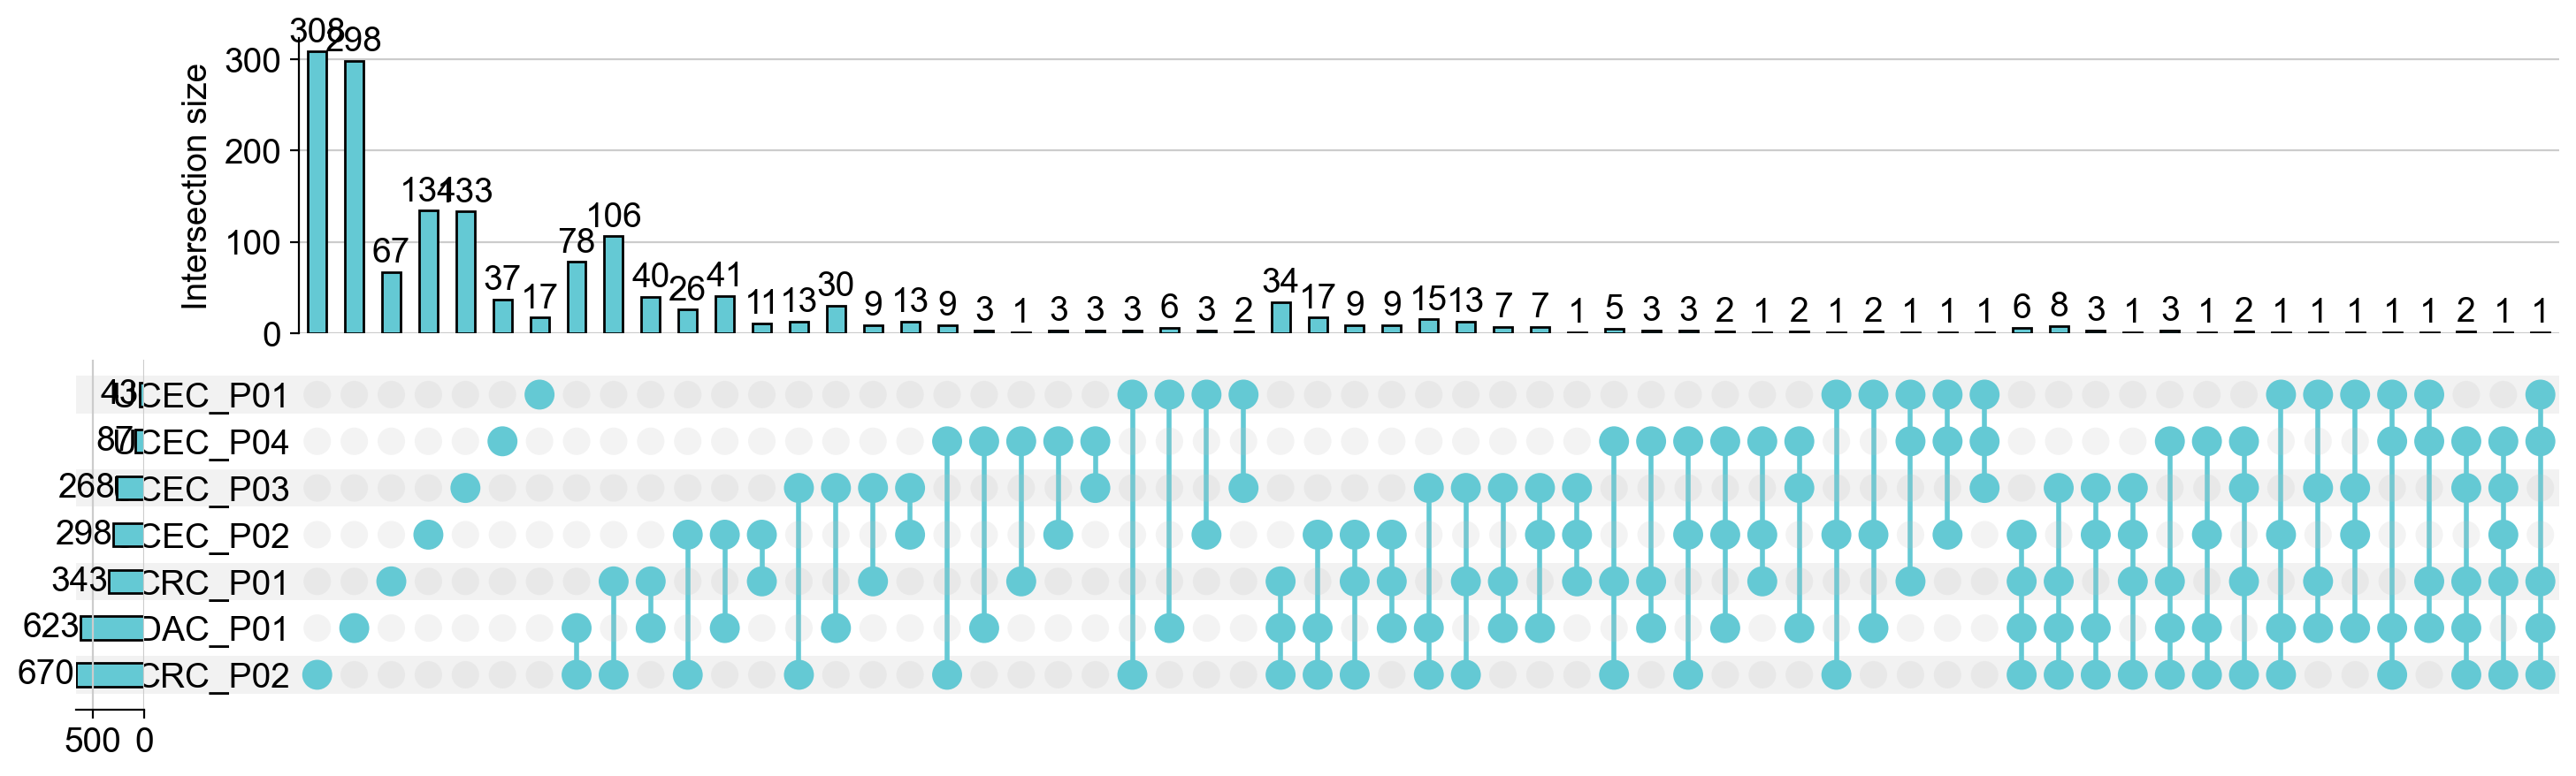

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import upsetplot

# 设置样本名称
sample_names = ["PDAC_P01", "CRC_P01", "CRC_P02", "UCEC_P01", "UCEC_P02", "UCEC_P03", "UCEC_P04"]

increased_list = []
for i, sample in enumerate(sample_names):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    #tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls",index_col=0)
    tb_temp = pd.read_table(primary_path + f"/f27-ecDNA_change-seu.markers_upsample-20250726.xls", index_col=0)
    # 1. 替换 "-" 为 "_"
    tb_temp["gene"] = tb_temp["gene"].str.replace("-", "_", regex=False)
    tb_temp.index = tb_temp["gene"]
    
    list_temp = tb_temp[
        (tb_temp["cluster"] == "Clone_Increased") & 
        (tb_temp["avg_log2FC"] > 1) & 
        (tb_temp["p_val"] < 0.05)
    ]["gene"].to_list()
    increased_list.append(list_temp)

# 构建 UpSet 数据内容
increased_contents = {sample_names[i]: set(lst) for i, lst in enumerate(increased_list)}

# 假设你已有 contents 字典
plot_colored_upsetplot(
    data=increased_contents,
    #title="Increased ecDNA CPRs",
    bar_color_top="#64c9d4",
    bar_color_side="#64c9d4",
    dot_edge_color="#64c9d4",
    dot_face_color_opaque="#64c9d4",       # 交集点
    dot_face_color_translucent="#c0c0c0",  # 灰色全集点
    save_path="D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/increased_contents3_genenamecor.pdf"
)

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_213588\318939306.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ 图像保存至: D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/decreased_contents3_genenamecor.pdf


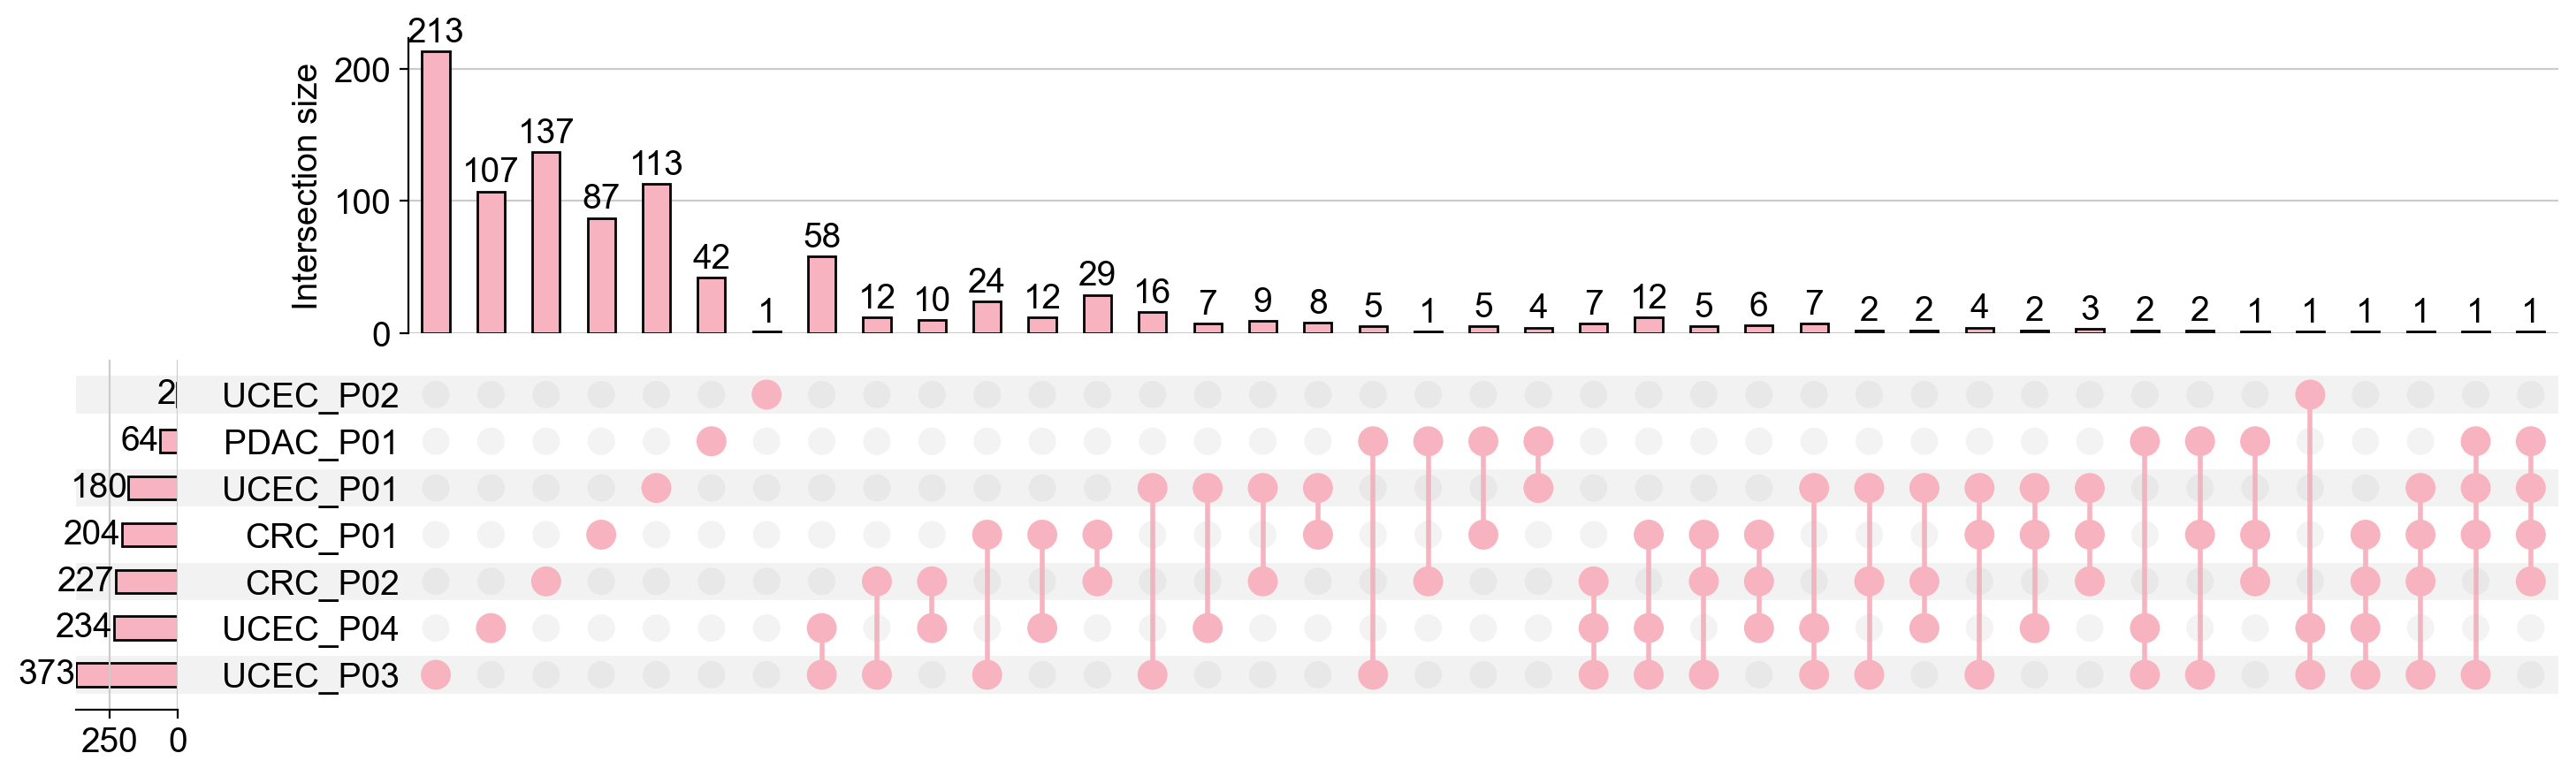

In [128]:
decreased_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    #tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls",index_col=0)
    tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers_upsample-20250726.xls",index_col=0)
    # 1. 替换 "-" 为 "_"
    tb_temp["gene"] = tb_temp["gene"].str.replace("-", "_", regex=False)
    tb_temp.index = tb_temp["gene"]
    list_temp = tb_temp[(tb_temp["cluster"]=="Clone_Decreased") & (tb_temp["avg_log2FC"]>1) & (tb_temp["p_val"]<0.05)]["gene"].to_list()
    decreased_list.append(list_temp)
    
# 构建 UpSet 数据内容
decreased_contents = {sample_names[i]: set(lst) for i, lst in enumerate(decreased_list)}

# 假设你已有 contents 字典
plot_colored_upsetplot(
    data=decreased_contents,
    #title="Decreased ecDNA CPRs",
    bar_color_top="#f7b3bf",
    bar_color_side="#f7b3bf",
    dot_edge_color="#f7b3bf",
    dot_face_color_opaque="#f7b3bf",       # 交集点
    dot_face_color_translucent="#c0c0c0",  # 灰色全集点
    save_path="D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/decreased_contents3_genenamecor.pdf"
)

C:\Users\wangyuhang\AppData\Local\Temp\ipykernel_213588\318939306.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ 图像保存至: D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/shared_contents3_genenamecor.pdf


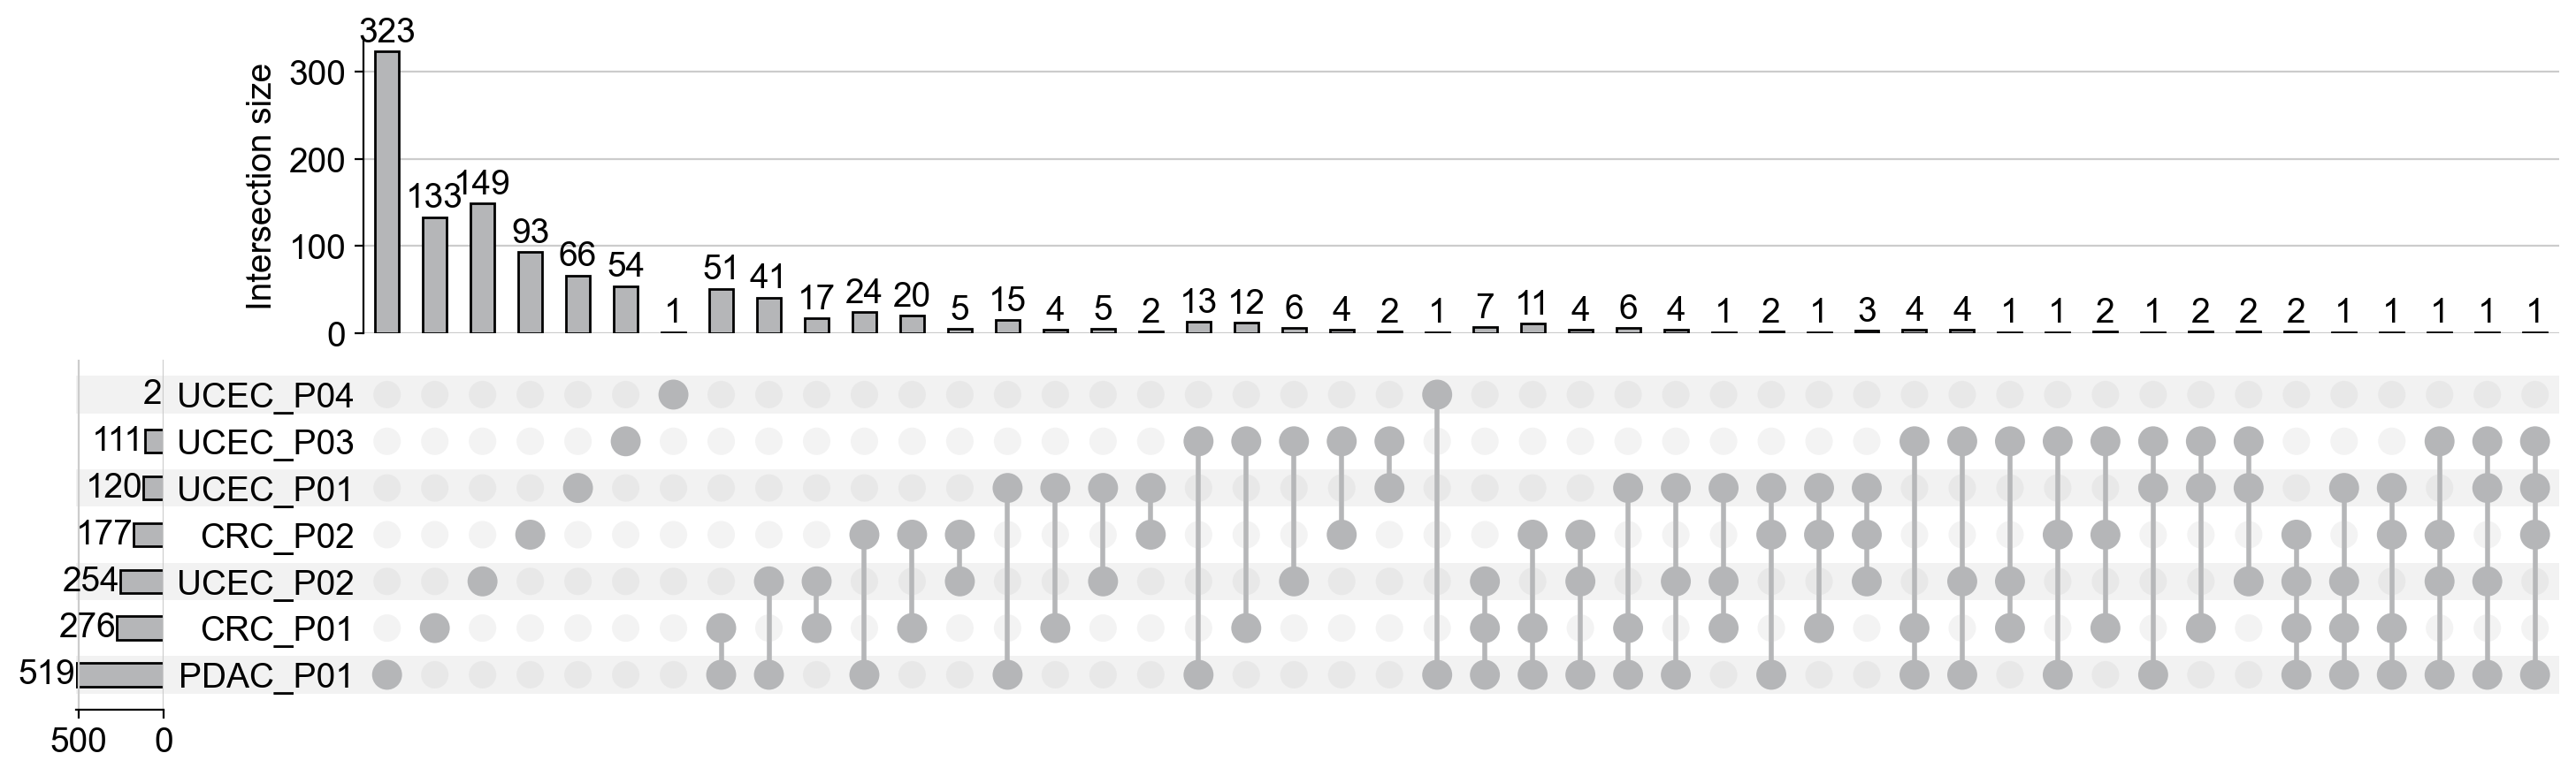

In [129]:
shared_list = list()
for i in range(7):
    primary_path = f"D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/s{i}"
    #tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers.xls",index_col=0)
    tb_temp = pd.read_table(primary_path+f"/f27-ecDNA_change-seu.markers_upsample-20250726.xls",index_col=0)
    # 1. 替换 "-" 为 "_"
    tb_temp["gene"] = tb_temp["gene"].str.replace("-", "_", regex=False)
    tb_temp.index = tb_temp["gene"]
    list_temp = tb_temp[(tb_temp["p_val_adj"]>=0.05)]["gene"].to_list()
    shared_list.append(list_temp)
    
# 构建 UpSet 数据内容
shared_contents = {sample_names[i]: set(lst) for i, lst in enumerate(shared_list)}

# 假设你已有 contents 字典
plot_colored_upsetplot(
    data=shared_contents,
    #title="Shared ecDNA CPRs",
    bar_color_top="#b5b6b8",
    bar_color_side="#b5b6b8",
    dot_edge_color="#b5b6b8",
    dot_face_color_opaque="#b5b6b8",       # 交集点
    dot_face_color_translucent="#c0c0c0",  # 灰色全集点
    save_path="D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/shared_contents3_genenamecor.pdf"
)

In [130]:
#### to gene 
# increased_contents
# shared_contents
# decreased_contents

In [152]:
upset_data = upsetplot.from_contents(increased_contents)
df_reset = upset_data.reset_index()
# 将前 7 列的值从 True/False 转换为 1/0
df_reset.iloc[:, :7] = df_reset.iloc[:, :7].astype(int)
# 计算前 7 列的和，并将结果作为新的一列添加到 DataFrame
df_reset['sum'] = df_reset.iloc[:, :7].sum(axis=1)
df_reset.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f01-upset_data-increased_contents.xls', sep='\t', index=True)
df_reset

df_cpr = df_reset
df_cpr["chr_raw"] = df_cpr["id"]
### anno ecdna2gene oncogene pathway
df_ecdna = df_cpr.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f01-upset_data-increased_contents-gene_oncogene.xls', sep='\t', index=True)


species value: hg38


In [155]:
#### 筛选 common ecDNA list
increased_contents3 = df_ecdna_gene[df_ecdna_gene["sum"] >= 3]
increased_contents3.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f01-upset_data-increased_contents-gene-sum3.xls', sep='\t', index=True)
len(increased_contents3)

167

In [142]:
shared_contents2["group"] = "Shared_ecDNA_collection" 
shared_contents3["group"] = "Shared_ecDNA_collection" 
shared_contents4["group"] = "Shared_ecDNA_collection" 

In [147]:
decreased_contents2["group"] = "Decreased_ecDNA_collection" 
decreased_contents3["group"] = "Decreased_ecDNA_collection" 
decreased_contents4["group"] = "Decreased_ecDNA_collection" 

In [156]:
increased_contents2["group"] = "Increased_ecDNA_collection" 
increased_contents3["group"] = "Increased_ecDNA_collection" 
increased_contents4["group"] = "Increased_ecDNA_collection" 

In [ ]:
# 合并三个 DataFrame（按行拼接）

In [166]:
df_merge2 = pd.concat([decreased_contents2, shared_contents2, increased_contents2], axis=0, ignore_index=True)
df_merge2.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f02-df_merge2.xls', 
                 sep='\t', index=True)
len(df_merge2)

1112

In [167]:
df_merge3 = pd.concat([decreased_contents3, shared_contents3, increased_contents3], axis=0, ignore_index=True)
df_merge3.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f02-df_merge3.xls', 
                 sep='\t', index=True)
len(df_merge3)

290

In [168]:
df_merge4 = pd.concat([decreased_contents4, shared_contents4, increased_contents4], axis=0, ignore_index=True)
df_merge4.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f02-df_merge4.xls', 
                 sep='\t', index=True)
len(df_merge4)

44

In [ ]:
#### merge

In [284]:
df_merge_onco = group_merge(df_merge4,"group","oncogene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_onco['oncogene_nor_number'] = df_merge_onco['oncogene_nor'].apply(lambda x: len(x))
df_merge_onco.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f02-df_merge4-onco.xls', 
                     sep='\t', index=True)
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
0,Decreased_ecDNA_collection,[],[],0
2,Shared_ecDNA_collection,[ERBB3],[ERBB3],1
1,Increased_ecDNA_collection,"[FSTL3, SETD1B, SH3GL1, CNBP, YWHAE, CHD4]","[FSTL3, SETD1B, SH3GL1, CNBP, YWHAE, CHD4]",6


In [285]:
df_merge_body = group_merge(df_merge4,"group","genebody_region_gene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_body['genebody_region_gene_nor_number'] = df_merge_body['genebody_region_gene_nor'].apply(lambda x: len(x))
df_merge_body.to_csv(f'D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/f02-df_merge4-body.xls', 
                     sep='\t', index=True)
df_merge_body

,group,genebody_region_gene_nor,most_genebody_region_gene_nor,genebody_region_gene_nor_number
0,Decreased_ecDNA_collection,"[LMTK3, CTC-273B12.10, SULT2B1, TCF20, LINC013...","[LMTK3, CTC-273B12.10, SULT2B1, TCF20, LINC013...",16
2,Shared_ecDNA_collection,"[CCDC62, HIP1R, VPS37B, RP11-463O12.3, RP11-46...","[CCDC62, HIP1R, VPS37B, RP11-463O12.3, RP11-46...",51
1,Increased_ecDNA_collection,"[PHRF1, IRF7, CDHR5, SCT, DRD4, DEAF1, RP11-75...","[PHRF1, IRF7, CDHR5, SCT, DRD4, DEAF1, RP11-75...",290


In [286]:
##### pathway

In [287]:
df_merge_onco = df_merge_onco[df_merge_onco['oncogene_nor_number'] != 0]
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
2,Shared_ecDNA_collection,[ERBB3],[ERBB3],1
1,Increased_ecDNA_collection,"[FSTL3, SETD1B, SH3GL1, CNBP, YWHAE, CHD4]","[FSTL3, SETD1B, SH3GL1, CNBP, YWHAE, CHD4]",6


In [288]:
gene_sets0=['MSigDB_Hallmark_2020',
            'KEGG_2021_Human',
            'GO_Biological_Process_2023',
            'GO_Molecular_Function_2023',
            'GO_Cellular_Component_2023']
gene_sets1=['MSigDB_Hallmark_2020']

In [289]:
gsea_path = os.getcwd()+'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/df_merge4_onco-5db/'
if not os.path.exists(gsea_path): os.makedirs(gsea_path, exist_ok=True)
enrich_list = []
for sample in df_merge_onco["group"].unique():
    print(sample)
    gene_list = df_merge_onco[df_merge_onco["group"]==sample]["oncogene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path,gene_sets=gene_sets0)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

Shared_ecDNA_collection
done.
Increased_ecDNA_collection
done.


In [290]:
enr_res_onco = pd.concat(enrich_list)
enr_res_onco["cluster"] = pd.Categorical(enr_res_onco["cluster"],
                                      categories=list(enr_res_onco["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_onco.to_csv('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/df_merge4_onco-5db/f04-gene-pathway.xls', sep='\t', index=True)

In [291]:
enr_res_onco["Gene_set"].value_counts()

GO_Biological_Process_2023    129
GO_Molecular_Function_2023     32
KEGG_2021_Human                17
GO_Cellular_Component_2023      9
MSigDB_Hallmark_2020            6
Name: Gene_set, dtype: int64

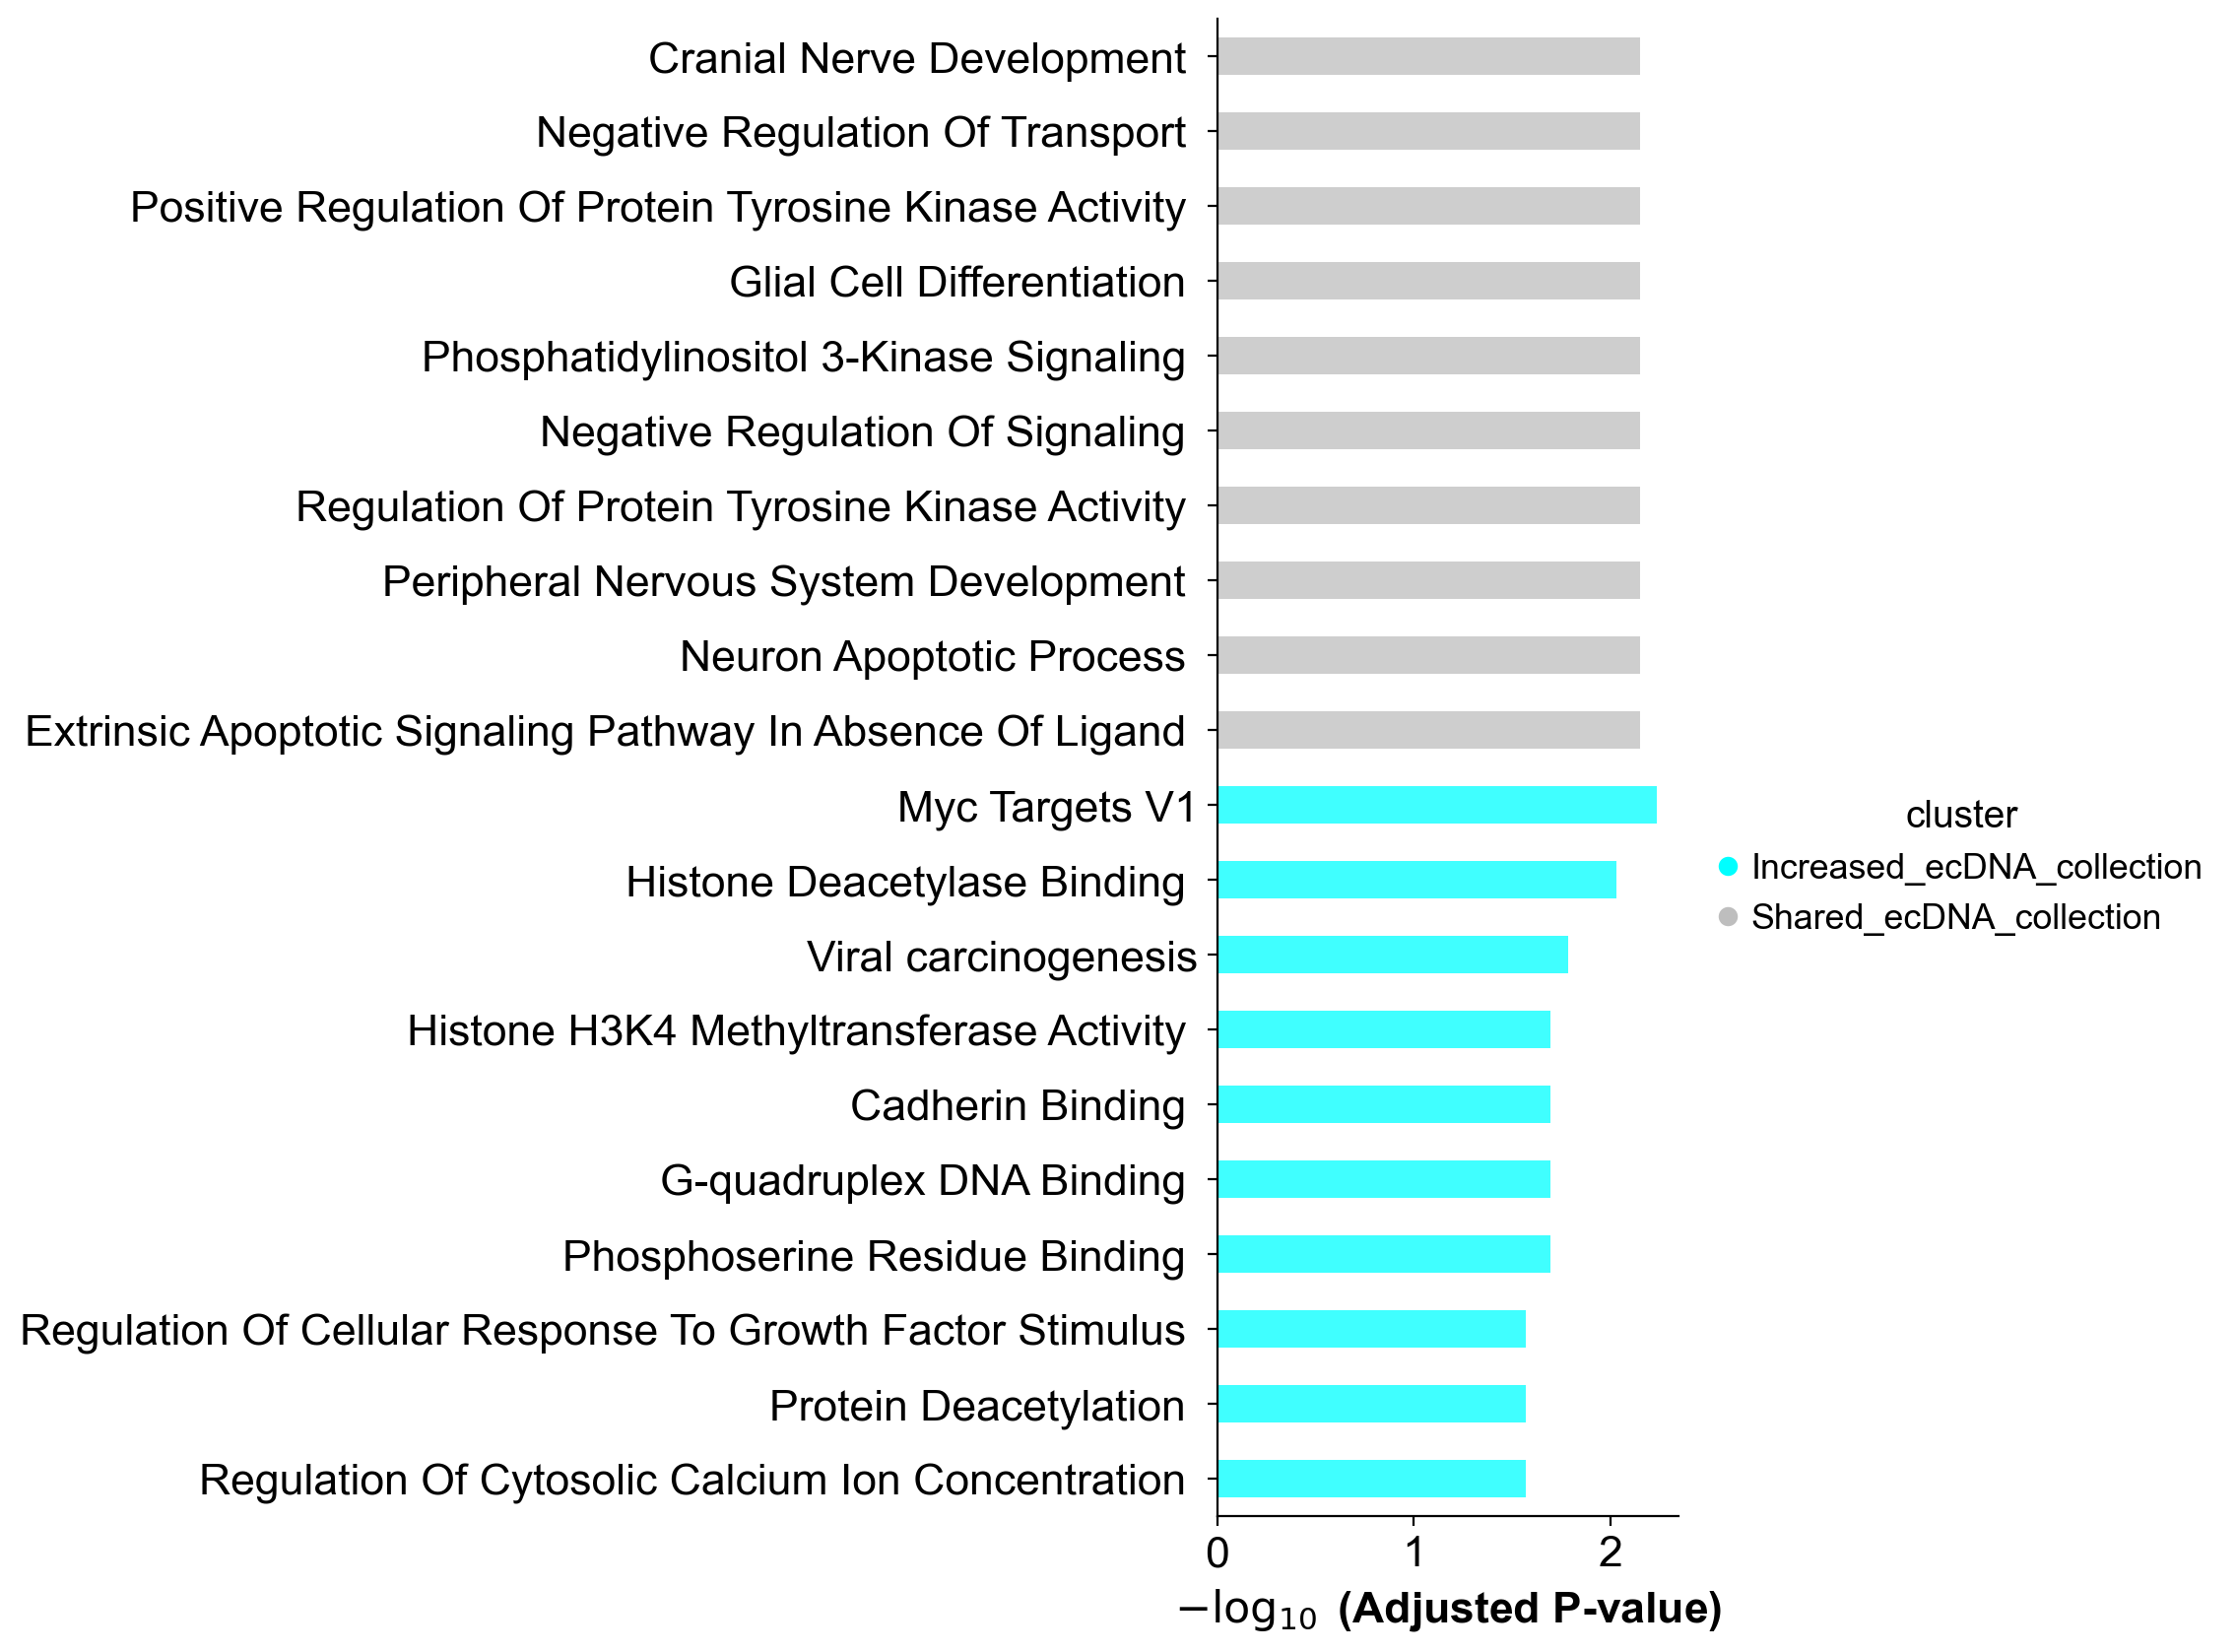

In [297]:
ax = barplot(
    enr_res_onco,
    #enr_res_onco[enr_res_onco["Gene_set"]=="KEGG_2021_Human"],
    #enr_res_onco[enr_res_onco["Gene_set"]=="MSigDB_Hallmark_2020"],
    #enr_res_onco[enr_res_onco["Gene_set"]=="GO_Biological_Process_2023"],
    #enr_res_onco[enr_res_onco["Gene_set"]=="GO_Molecular_Function_2023"],
    #enr_res_onco[enr_res_onco["Gene_set"]=="GO_Cellular_Component_2023"],
    column="Adjusted P-value",
    #column="P-value",
    group ='cluster',
    #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
    size=0.2,
    top_term=10,
    #figsize=(4,0.5*len(enr_res_onco[enr_res_onco["Adjusted P-value"] <= 0.05])/20),
    figsize=(3,10),
    #color=bright_morandi_colors
    color=['#ffc0cb',"#bebebe",'#00ffff',][::-1], # set colors for group
    #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
    )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/df_merge4_onco-5db/f05-gene-pathway-alltop.pdf', bbox_inches='tight')

In [298]:
### body gene

In [299]:
df_merge_body = df_merge_body[df_merge_body['genebody_region_gene_nor_number'] != 0]
df_merge_body

,group,genebody_region_gene_nor,most_genebody_region_gene_nor,genebody_region_gene_nor_number
0,Decreased_ecDNA_collection,"[LMTK3, CTC-273B12.10, SULT2B1, TCF20, LINC013...","[LMTK3, CTC-273B12.10, SULT2B1, TCF20, LINC013...",16
2,Shared_ecDNA_collection,"[CCDC62, HIP1R, VPS37B, RP11-463O12.3, RP11-46...","[CCDC62, HIP1R, VPS37B, RP11-463O12.3, RP11-46...",51
1,Increased_ecDNA_collection,"[PHRF1, IRF7, CDHR5, SCT, DRD4, DEAF1, RP11-75...","[PHRF1, IRF7, CDHR5, SCT, DRD4, DEAF1, RP11-75...",290


In [301]:
gsea_path = os.getcwd()+'./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/df_merge4_body-5db/'
if not os.path.exists(gsea_path): os.makedirs(gsea_path, exist_ok=True)
enrich_list = []
for sample in df_merge_body["group"].unique():
    print(sample)
    gene_list = df_merge_body[df_merge_body["group"]==sample]["genebody_region_gene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path,gene_sets=gene_sets0)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

Decreased_ecDNA_collection
done.
Shared_ecDNA_collection
done.
Increased_ecDNA_collection
done.


In [302]:
enr_res_body = pd.concat(enrich_list)
enr_res_body["cluster"] = pd.Categorical(enr_res_body["cluster"],
                                      categories=list(enr_res_body["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_body.to_csv('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/df_merge4_body-5db/f04-gene-pathway.xls', sep='\t', index=True)

In [303]:
enr_res_body["Gene_set"].value_counts()

GO_Biological_Process_2023    1606
GO_Molecular_Function_2023     308
KEGG_2021_Human                280
GO_Cellular_Component_2023     200
MSigDB_Hallmark_2020            68
Name: Gene_set, dtype: int64

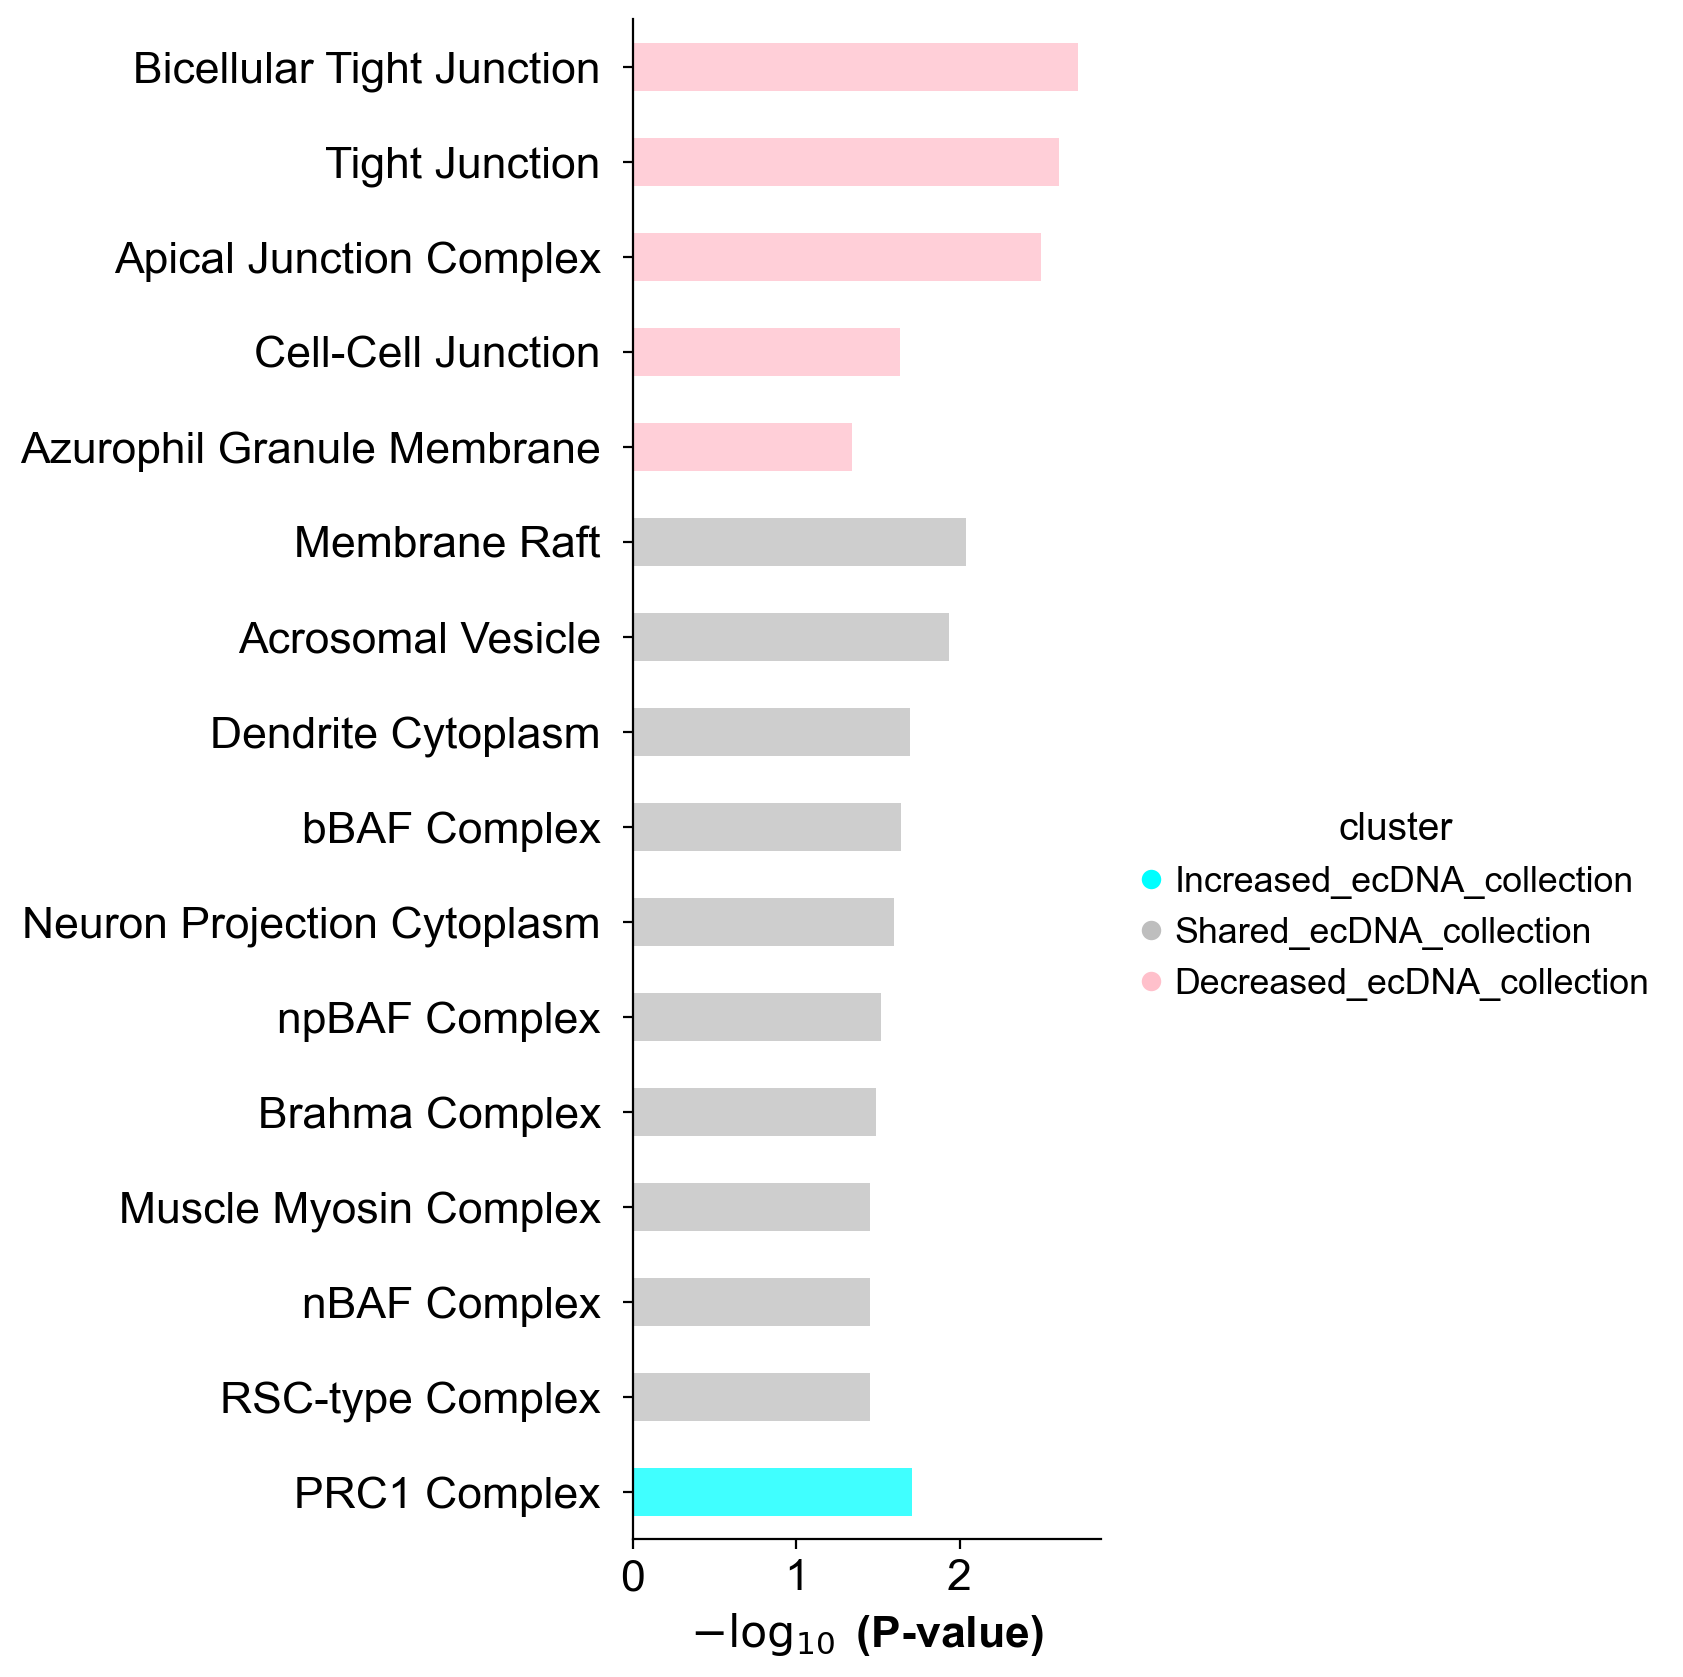

In [310]:
ax = barplot(
    #enr_res_body,
    #enr_res_body[enr_res_body["Gene_set"]=="KEGG_2021_Human"],
    #enr_res_body[enr_res_body["Gene_set"]=="MSigDB_Hallmark_2020"],
    #enr_res_body[enr_res_body["Gene_set"]=="GO_Biological_Process_2023"],
    #enr_res_body[enr_res_body["Gene_set"]=="GO_Molecular_Function_2023"],
    enr_res_body[enr_res_body["Gene_set"]=="GO_Cellular_Component_2023"],
    column="P-value",
    #column="P-value",
    group ='cluster',
    #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
    size=0.2,
    top_term=10,
    #figsize=(4,0.5*len(enr_res_body[enr_res_body["Adjusted P-value"] <= 0.05])/20),
    figsize=(3,10),
    #color=bright_morandi_colors
    color=['#ffc0cb',"#bebebe",'#00ffff',][::-1], # set colors for group
    #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
    )
plt.grid(False)
plt.savefig('./fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/df_merge4_body-5db/f05-gene-pathway-GOCC.pdf', bbox_inches='tight')

In [311]:
#### circle viz

In [312]:
#### generate circle viz pre-files
### import generate_circle_viz_pre_files function

### 准备文件 ：生成 Circle_Viz 函数所需的输入文件
### 判断cpr是否相邻
def function_a(element1, element2):
    chr1, range1 = element1.split(':')
    chr2, range2 = element2.split(':')
    
    if chr1 != chr2:
        return False, element1
    
    start1, end1 = map(int, range1.split('_'))
    start2, end2 = map(int, range2.split('_'))
    
    if end1 == start2:
        return True, f"{chr1}:{start1}_{end2}"
    elif end2 == start1:
        return True, f"{chr1}:{start2}_{end1}"
    else:
        return False, element1
### 将相邻的cpr合并
def merge_elements(list_a):
    list_new = sorted(list_a)
    while True:
        merged = False
        temp_list = []
        i = 0
        while i < len(list_new):
            if i < len(list_new) - 1:
                is_adjacent, merged_element = function_a(list_new[i], list_new[i + 1])
                if is_adjacent:
                    temp_list.append(merged_element)
                    i += 2
                    merged = True
                else:
                    temp_list.append(list_new[i])
                    i += 1
            else:
                temp_list.append(list_new[i])
                i += 1
        list_new = sorted(temp_list) # 在每次迭代中对列表进行排序，确保所有可能的连续元素都被正确合并
        if not merged:
            break
    return list_new
def generate_txt(list_new, filename):
    with open(filename, 'w') as file:
        file.write("SequenceEdge: StartPosition, EndPosition, PredictedCopyCount, AverageCoverage, Size, NumberReadsMapped\n")
        for element in list_new:
            chr_range = element.split(':')
            chr_name = chr_range[0]
            start_end = chr_range[1].split('_')
            start = start_end[0]
            end = start_end[1]
            file.write(f"sequence\t{chr_name}:{start}-\t{chr_name}:{end}+\t6\t18\t100000\t100\n")
        file.write("BreakpointEdge: StartPosition->EndPosition, PredictedCopyCount, NumberOfReadPairs, HomologySizeIfAvailable(<0ForInsertions), Homology/InsertionSequence\n")

def circle_graph_file(df,outfile_path):  
    if(os.path.exists(outfile_path) != True): os.makedirs(outfile_path)
    os.chdir(outfile_path)
    print(os.getcwd())
    
    df.reset_index(drop=True, inplace=True)
    # 第一步：生成新的 txt 文件
    with open('amplicon_cycles.txt', 'w') as file:
        for i, name in enumerate(df['names'], start=1):
            chr_part, positions = name.split(':')
            start_pos, end_pos = positions.split('_')
            file.write(f"Interval\t{i}\t{chr_part}\t{start_pos}\t{end_pos}\n")
        file.write("List of cycle segments\n")
    
    # 第二步：将连续元素合并为一个元素
    merged_names = merge_elements(df['names'].to_list())
    
    # 第三步：写入 Segment 开头的行
    with open('amplicon_cycles.txt', 'a') as file:
        for i, name in enumerate(merged_names, start=1):
            chr_part, positions = name.split(':')
            start_pos, end_pos = positions.split('_')
            file.write(f"Segment\t{i}\t{chr_part}\t{start_pos}\t{end_pos}\n")
    
    # 第四步：写入 Cycle 开头的行
    with open('amplicon_cycles.txt', 'a') as file:
        #file.write("Cycle=1;Copy_count=18;Segments=")
        segments = "".join([f"{i}+," for i in range(1, len(merged_names) + 1)])
        if segments.endswith(","):
            segments = segments[:-1]
        file.write(f"Cycle=1;Copy_count=18;Segments={segments}\n")
    
        sorted_segments = sorted(range(1, len(merged_names) + 1), key=lambda x: (merged_names[x-1].split(':')[0], 
                                                                                 int(merged_names[x-1].split(':')[1].split('_')[0])))
        #file.write("Cycle=2;Copy_count=18;Segments=")
        segments = "".join([f"{i}+," for i in sorted_segments])
        if segments.endswith(","):
            segments = segments[:-1]
        file.write(f"Cycle=2;Copy_count=18;Segments={segments}\n")
    
    print("Done: amplicon_cycles.txt")
    
    ### step II
    generate_txt(merged_names, "amplicon_graph.txt")
    print("Done: amplicon_graph.txt")
    


In [330]:
import os

def is_adjacent_and_merge(region1, region2, gap_tolerance=0):
    """判断两个基因区段是否相邻（允许gap容忍）并合并"""
    chr1, pos1 = region1.split(':')
    chr2, pos2 = region2.split(':')

    if chr1 != chr2:
        return False, region1

    start1, end1 = map(int, pos1.split('_'))
    start2, end2 = map(int, pos2.split('_'))

    if abs(end1 - start2) <= gap_tolerance:
        return True, f"{chr1}:{min(start1, start2)}_{max(end1, end2)}"
    elif abs(end2 - start1) <= gap_tolerance:
        return True, f"{chr1}:{min(start1, start2)}_{max(end1, end2)}"
    else:
        return False, region1


def merge_adjacent_intervals(region_list, gap_tolerance=0):
    """递归合并相邻区段"""
    merged_list = sorted(set(region_list))
    while True:
        merged = False
        temp_list = []
        i = 0
        while i < len(merged_list):
            if i < len(merged_list) - 1:
                is_adjacent, merged_region = is_adjacent_and_merge(
                    merged_list[i], merged_list[i + 1], gap_tolerance
                )
                if is_adjacent:
                    temp_list.append(merged_region)
                    i += 2
                    merged = True
                else:
                    temp_list.append(merged_list[i])
                    i += 1
            else:
                temp_list.append(merged_list[i])
                i += 1
        merged_list = sorted(set(temp_list), key=lambda x: (x.split(':')[0], int(x.split(':')[1].split('_')[0])))
        if not merged:
            break
    return merged_list


def write_amplicon_graph_file(region_list, filepath, copy_count=6, coverage=100000, reads=100):
    """写入 amplicon_graph.txt 文件"""
    with open(filepath, 'w') as file:
        file.write("SequenceEdge: StartPosition, EndPosition, PredictedCopyCount, AverageCoverage, Size, NumberReadsMapped\n")
        for region in region_list:
            chrom, pos = region.split(':')
            start, end = pos.split('_')
            file.write(f"sequence\t{chrom}:{start}-\t{chrom}:{end}+\t{copy_count}\t18\t{coverage}\t{reads}\n")
        file.write("BreakpointEdge: StartPosition->EndPosition, PredictedCopyCount, NumberOfReadPairs, HomologySizeIfAvailable(<0ForInsertions), Homology/InsertionSequence\n")


def write_amplicon_cycles_file(df_names, merged_names, filepath, copy_count=18):
    """写入 amplicon_cycles.txt 文件（包含 Interval、Segment、Cycle）"""
    with open(filepath, 'w') as file:
        # Interval 行
        for i, name in enumerate(df_names, start=1):
            chrom, pos = name.split(':')
            start, end = pos.split('_')
            file.write(f"Interval\t{i}\t{chrom}\t{start}\t{end}\n")
        file.write("List of cycle segments\n")

        # Segment 行
        for i, name in enumerate(merged_names, start=1):
            chrom, pos = name.split(':')
            start, end = pos.split('_')
            file.write(f"Segment\t{i}\t{chrom}\t{start}\t{end}\n")

        # Cycle 1: 顺序 segments
        segments_1 = ",".join([f"{i}+" for i in range(1, len(merged_names) + 1)])
        file.write(f"Cycle=1;Copy_count={copy_count};Segments={segments_1}\n")

        # Cycle 2: 排序 segments（按染色体和起始位置）
        sorted_indices = sorted(
            range(1, len(merged_names) + 1),
            key=lambda i: (merged_names[i - 1].split(':')[0], int(merged_names[i - 1].split(':')[1].split('_')[0]))
        )
        segments_2 = ",".join([f"{i}+" for i in sorted_indices])
        file.write(f"Cycle=2;Copy_count={copy_count};Segments={segments_2}\n")


def generate_circle_viz_pre_files(df, outdir, gap_tolerance=0):
    """
    主函数：生成 CircleViz 所需的 amplicon_cycles.txt 和 amplicon_graph.txt
    参数：
        df: 包含 'names' 列（格式如 chr1:100_200）
        outdir: 输出目录
        gap_tolerance: 判断相邻的最大允许 gap（bp）
    """
    os.makedirs(outdir, exist_ok=True)

    df = df.reset_index(drop=True)
    df_names = df['names'].tolist()
    merged_names = merge_adjacent_intervals(df_names, gap_tolerance=gap_tolerance)

    # 文件路径
    cycles_path = os.path.join(outdir, 'amplicon_cycles.txt')
    graph_path = os.path.join(outdir, 'amplicon_graph.txt')

    # 写文件
    write_amplicon_cycles_file(df_names, merged_names, cycles_path)
    print(f"✓ Done: {cycles_path}")

    write_amplicon_graph_file(merged_names, graph_path)
    print(f"✓ Done: {graph_path}")


In [339]:
### 输入
df_merge4["names"] = df_merge4["chr_raw"]
df_merge4_in = df_merge4[df_merge4["group"]=="Increased_ecDNA_collection"]
len(df_merge4_in)

33

In [354]:
### 输入
df_merge4["names"] = df_merge4["chr_raw"]
df_merge4_de = df_merge4[df_merge4["group"]=="Decreased_ecDNA_collection"]
len(df_merge4_de)
### 输入
df_merge4["names"] = df_merge4["chr_raw"]
df_merge4_sh = df_merge4[df_merge4["group"]=="Shared_ecDNA_collection"]
len(df_merge4_sh)

7

In [340]:
### step 1 筛选 多次的chr
# 提取 chr 信息（"chr11:600000_700000" -> "chr11"）
df_merge4_in['chr'] = df_merge4_in['names'].str.split(':').str[0]
# 统计每种 chr 出现次数
chr_counts = df_merge4_in['chr'].value_counts()
# 判断该行所在 chr 是否出现超过一次
df_merge4_in['chr_duplicated'] = df_merge4_in['chr'].map(chr_counts) >= 2
### step 2 筛选 oncogene的cpr
# 判断 df_merge4_in["oncogene"] 每一行是否是非空列表（即是否包含至少一个候选基因），并生成一个新的布尔列
df_merge4_in["has_oncogene"] = df_merge4_in["oncogene"].apply(lambda x: len(x) > 0)
### step 3 合并筛选
# 逻辑或操作，保留符合 chr_duplicated 或 has_oncogene 为 True 的行
df_merge4_in_pos = df_merge4_in[df_merge4_in['chr_duplicated'] | df_merge4_in['has_oncogene']]
len(df_merge4_in_pos)

26

In [355]:
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_in"
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_in2"
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_in_pos"
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_de"
outfile_path = "D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_sh"
if(os.path.exists(outfile_path) != True): os.makedirs(outfile_path)
os.chdir(outfile_path)
print(os.getcwd())

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\02.cluster_nx\common\circle\df_merge4_sh


In [356]:
### 存 ecDNA 文件
df_merge4_sh.to_csv('./amplicon_cpr.xls', sep='\t', index=True)

In [318]:
circle_graph_file(df=df_merge4_in,outfile_path=outfile_path)

D:\02.project\18.ecDNA\02.code\v0.1.1\fig_cpr_rbg_stat_2\07.tracing\02.cluster_nx\common\circle\df_merge4_in
Done: amplicon_cycles.txt
Done: amplicon_graph.txt


In [357]:
generate_circle_viz_pre_files(df=df_merge4_sh, outdir=outfile_path)

✓ Done: D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_sh\amplicon_cycles.txt
✓ Done: D:/02.project/18.ecDNA/02.code/v0.1.1/fig_cpr_rbg_stat_2/07.tracing/02.cluster_nx/common/circle/df_merge4_sh\amplicon_graph.txt


In [319]:
#### circle graph

In [348]:
#### 错误
###  1 chr 排序
###  2 amplicon_BPG_converted_cycles.txt 错误

In [358]:
### 手动标红oncogene
#!python D:\CycleViz\CycleViz.py  --ref hg38 --cycles_file amplicon_cycles.txt --cycle 1 -g amplicon_graph.txt --rotate_to_min --figure_size_style normal --gene_highlight_list FSTL3 SETD1B SH3GL1 CNBP YWHAE CHD4
### 只显示 BUSHMAN 实验室发布的 oncogene "Bushman_group_allOnco_May2018.tsv"
#!python D:\CycleViz\CycleViz.py  --ref hg38 --cycles_file amplicon_cycles.txt --cycle 1 -g amplicon_graph.txt --rotate_to_min --figure_size_style normal --gene_subset_file BUSHMAN --gene_highlight_list FSTL3 SETD1B SH3GL1 CNBP YWHAE CHD4

### 手动标红oncogene
!python D:\CycleViz\CycleViz.py  --ref hg38 --cycles_file amplicon_cycles.txt --cycle 1 -g amplicon_graph.txt --rotate_to_min --figure_size_style normal --gene_highlight_list ERBB3

CycleViz 0.2.0
Using resources in D:\CycleViz/resources/
Plots will use reference hg38
Converting cycles file segment boundaries to graph file segment boundaries
amplicon_BPG_converted_cycles.txt
checking adjacency
plotting structure
Reading genes
plotting genes
saving PNG
saving PDF
finished

